Dataset Link - https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small

In [ ]:
!pip install kaggle -q

In [ ]:
#Importing libraries
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
import zipfile
import tqdm
from tqdm import tqdm
import pandas as pd
import numpy as np
import pickle as pkl
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPool2D

from sklearn.neighbors import NearestNeighbors
import os
from numpy.linalg import norm

Data Collection

In [ ]:
kaggle_config = json.load(open("kaggle.json"))  # login to kaggle > verify account > profile icon > settings > create new API token

In [ ]:
kaggle_config.keys()

dict_keys(['username', 'key'])

In [ ]:
# Set the environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_config['username']
os.environ['KAGGLE_KEY'] = kaggle_config['key']

In [ ]:
# loadig the dataset using kaggle api
!kaggle datasets download paramaggarwal/fashion-product-images-small

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
fashion-product-images-small.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!ls

fashion-product-images-small.zip  kaggle.json	 sample_data
images				  myntradataset  styles.csv


In [ ]:
with zipfile.ZipFile('fashion-product-images-small.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
image_dir = "/content/images"

filenames = [
    os.path.join(image_dir, file)
    for file in os.listdir(image_dir)
    if file.lower().endswith((".jpg", ".png", ".jpeg"))
]

In [ ]:
len(filenames)

44441

In [ ]:
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model.trainable = False

model = tf.keras.models.Sequential([model,
                                   GlobalMaxPool2D()
                                   ])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

#Extracting features from images

In [ ]:
def extract_features_from_images(image_path, model):
    """Extract normalized feature vector from an image using ResNet50."""
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_expand_dim = np.expand_dims(img_array, axis=0)
    img_preprocess = preprocess_input(img_expand_dim)
    result = model.predict(img_preprocess, verbose=0).flatten()
    norm_result = result / norm(result)
    return norm_result

# Quick test on the first image
test_feature = extract_features_from_images(filenames[0], model)
print('✅ Feature vector shape:', test_feature.shape)
print('Sample values:', test_feature[:5])

✅ Feature vector shape: (2048,)
Sample values: [0.00909221 0.02106975 0.01401168 0.         0.02495473]


In [ ]:
PKL_FEATURES = '/content/Images_features.pkl'
PKL_FILENAMES = '/content/filenames.pkl'

# Check if pre-computed features already exist (avoids re-running)
if os.path.exists(PKL_FEATURES) and os.path.exists(PKL_FILENAMES):
    print('📂 Found existing .pkl files — loading them...')
    Image_features = pkl.load(open(PKL_FEATURES, 'rb'))
    filenames = pkl.load(open(PKL_FILENAMES, 'rb'))
    print(f'✅ Loaded {len(Image_features)} feature vectors.')
else:
    print(f'🔄 Extracting features from {len(filenames)} images...')
    Image_features = []
    valid_filenames = []

    for file in tqdm(filenames, desc='Extracting features'):
        try:
            feat = extract_features_from_images(file, model)
            Image_features.append(feat)
            valid_filenames.append(file)
        except Exception as e:
            print(f'⚠️ Skipping {file}: {e}')

    filenames = valid_filenames  # update to only valid files

    # Save to disk
    pkl.dump(Image_features, open(PKL_FEATURES, 'wb'))
    pkl.dump(filenames, open(PKL_FILENAMES, 'wb'))
    print(f'✅ Features saved to {PKL_FEATURES}')

print('Feature array shape:', np.array(Image_features).shape)

🔄 Extracting features from 44441 images...


Extracting features: 100%|██████████| 44441/44441 [1:08:52<00:00, 10.75it/s]


✅ Features saved to /content/Images_features.pkl
Feature array shape: (44441, 2048)


Building KNN model for similiraty search

In [ ]:
neighbors = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='euclidean')
neighbors.fit(Image_features)
print('✅ KNN model fitted on', len(Image_features), 'images.')

✅ KNN model fitted on 44441 images.


In [ ]:
# ✏️ Change the index to test with different images, or replace with your own image path
QUERY_INDEX = 1145  # Index from filenames list
input_image_path = filenames[QUERY_INDEX]

# --- OR upload your own image ---
# uploaded = files.upload()
# input_image_path = list(uploaded.keys())[0]

print(f'Query image: {input_image_path}')

Query image: /content/images/21507.jpg


In [ ]:
# Extract features from the query image
input_features = extract_features_from_images(input_image_path, model)

# Find the 6 nearest neighbors (index 0 is the image itself)
distance, indices = neighbors.kneighbors([input_features])

print('Nearest neighbor indices:', indices[0])
print('Distances:', distance[0])

Nearest neighbor indices: [ 1145 16167 40776 15580 39224 36774]
Distances: [2.10734239e-08 5.68926692e-01 5.89405835e-01 6.01767540e-01
 6.08214796e-01 6.10026062e-01]


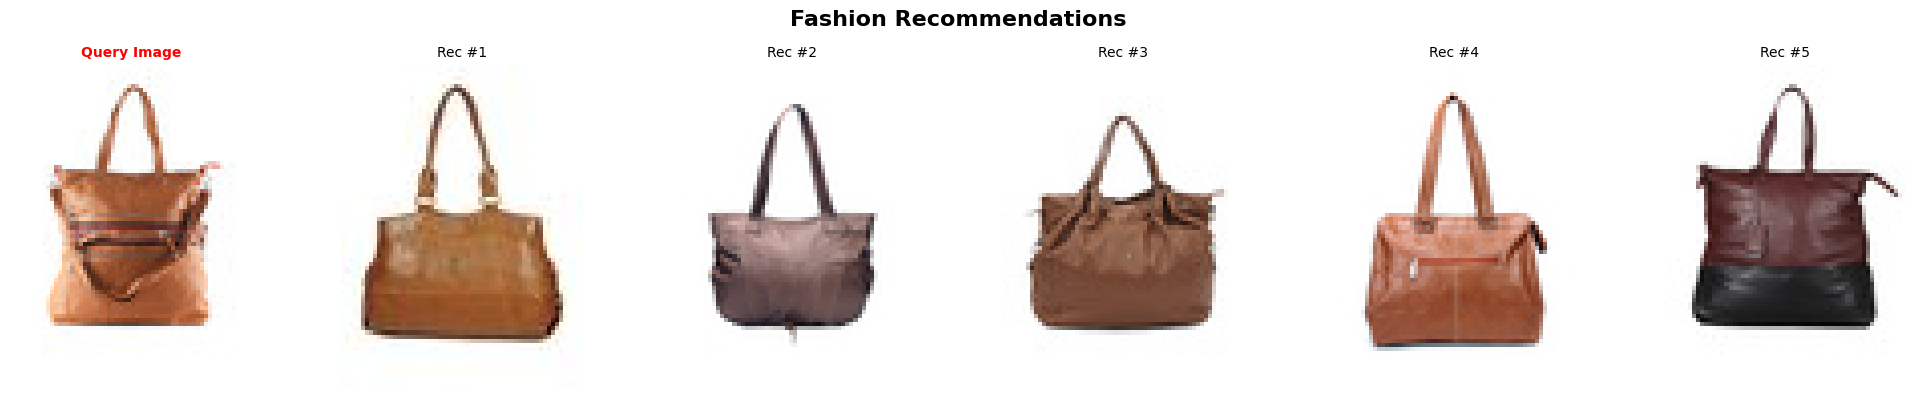

In [ ]:
def show_recommendations(query_path, indices, filenames, n_recommendations=5):
    """Display the query image and its top N similar fashion items."""
    fig, axes = plt.subplots(1, n_recommendations + 1, figsize=(20, 4))
    fig.suptitle('Fashion Recommendations', fontsize=16, fontweight='bold')

    # Query image
    axes[0].imshow(mpimg.imread(query_path))
    axes[0].set_title('Query Image', fontsize=10, color='red', fontweight='bold')
    axes[0].axis('off')

    # Recommended images (skip index 0 as it's the query image itself)
    for i, idx in enumerate(indices[0][1:n_recommendations + 1]):
        axes[i + 1].imshow(mpimg.imread(filenames[idx]))
        axes[i + 1].set_title(f'Rec #{i + 1}', fontsize=10)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

show_recommendations(input_image_path, indices, filenames)

In [ ]:
"""
from google.colab import files

# Upload an image from your local machine
uploaded = files.upload()
uploaded_image_path = list(uploaded.keys())[0]

print(f'Uploaded: {uploaded_image_path}')

# Get features and recommendations
uploaded_features = extract_features_from_images(uploaded_image_path, model)
dist, idx = neighbors.kneighbors([uploaded_features])

show_recommendations(uploaded_image_path, idx, filenames)